In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from rich.progress import Progress
from rich.console import Console
import sys
import datetime



df = pd.read_csv('data/nestlect.csv')

df.head()

,COMPANY_NAME,PLANT_NAME,EQUIPMENT_CODE,COUNTER_CODE,SHOT_START_TIME,SHOT_END_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT1UNIT,CYCLE_TIME_LIMIT2,CYCLE_TIME_LIMIT2UNIT,...,TOTAL_SESSION_TIME,START_TIME,END_TIME,IDLE_TIME,UPTIME_PERCENTAGE,DAY,MONTH,QUARTER,YEAR,WEEK
0,Rosti,Rosti Poland,T1-54110-ROSTI,EMA2324M10928,1720377539000000000,1720381152000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3627,20240707 18:38:59,20240707 19:39:12,31,99.15,20240707,202407,20243,2024,202427
1,WIK Macedonia,"Prilep, North Macedonia",9770.12-020T11,EMA2324M11490,1728328070000000000,1728331650000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3595,20241007 19:07:50,20241007 20:07:30,37,98.97,20241007,202410,20244,2024,202441
2,WIK Batam,"WIK Batam, Indonesia",9781.12-011T5,EMA2252M10434,1692668339000000000,1692671922000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3594,20230822 01:38:59,20230822 02:38:42,1599,55.51,20230822,202308,20233,2023,202334
3,Switzerland Nolato,Nolato CH,T2-18239,EMA2303M10685,1717085400000000000,1717088975000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3600,20240530 16:10:00,20240530 17:09:35,24,99.33,20240530,202405,20242,2024,202422
4,WIK Batam,"WIK Batam, Indonesia",9744.12-028T19,EMA2324M11666,1731111226000000000,1731114812000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3671,20241109 00:13:46,20241109 01:13:32,121,96.70,20241109,202411,20244,2024,202445


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672700 entries, 0 to 672699
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   COMPANY_NAME           669889 non-null  object 
 1   PLANT_NAME             630857 non-null  object 
 2   EQUIPMENT_CODE         630857 non-null  object 
 3   COUNTER_CODE           672700 non-null  object 
 4   SHOT_START_TIME        672700 non-null  int64  
 5   SHOT_END_TIME          672700 non-null  int64  
 6   CYCLE_TIME_LIMIT1      630857 non-null  float64
 7   CYCLE_TIME_LIMIT1UNIT  630857 non-null  object 
 8   CYCLE_TIME_LIMIT2      630857 non-null  float64
 9   CYCLE_TIME_LIMIT2UNIT  630857 non-null  object 
 10  L1_ABOVE_ADJUSTED      630857 non-null  float64
 11  L2_ABOVE_ADJUSTED      630857 non-null  float64
 12  L1_BELOW_ADJUSTED      630857 non-null  float64
 13  L2_BELOW_ADJUSTED      630857 non-null  float64
 14  CONTRACTED_CYCLE_TIME  630857 non-nu

In [3]:
# Filter data for Jasz Plastics and Rosti
filtered_data = df[df['COMPANY_NAME'].isin(['Jasz Plasztik Ltd', 'Rosti'])]



In [4]:
# Convert DAY to string format to handle it easily
filtered_data['DAY'] = filtered_data['DAY'].astype(str)

# Filter out data from 2020 (assuming the data from 2020 is irrelevant)
filtered_data = filtered_data[~filtered_data['DAY'].str.startswith('2020')]

# Optionally, if you expect data from 2023 or 2024:
filtered_data = filtered_data[filtered_data['DAY'].str.startswith(('2023', '2024'))]

# Convert DAY back to int after filtering
filtered_data['DAY'] = filtered_data['DAY'].astype(int)

# Now you can proceed with your previous calculations for mode and fluctuation


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/633947828.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['DAY'] = filtered_data['DAY'].astype(str)


In [5]:
filtered_data.head()

,COMPANY_NAME,PLANT_NAME,EQUIPMENT_CODE,COUNTER_CODE,SHOT_START_TIME,SHOT_END_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT1UNIT,CYCLE_TIME_LIMIT2,CYCLE_TIME_LIMIT2UNIT,...,TOTAL_SESSION_TIME,START_TIME,END_TIME,IDLE_TIME,UPTIME_PERCENTAGE,DAY,MONTH,QUARTER,YEAR,WEEK
0,Rosti,Rosti Poland,T1-54110-ROSTI,EMA2324M10928,1720377539000000000,1720381152000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3627,20240707 18:38:59,20240707 19:39:12,31,99.15,20240707,202407,20243,2024,202427
33,Jasz Plasztik Ltd,Jasz Hungary,TJ2-JDPLS1004522-JASZ,EMA2324M10582,1727987554000000000,1727991136000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3564,20241003 20:32:34,20241003 21:32:16,54,98.48,20241003,202410,20244,2024,202440
37,Jasz Plasztik Ltd,Jasz Hungary,TJ2-JDPLS1004721-JASZ,EMA2324M11293,1730198619000000000,1730202186000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3585,20241029 10:43:39,20241029 11:43:06,47,98.69,20241029,202410,20244,2024,202444
41,Jasz Plasztik Ltd,Jasz Hungary,TJ1-54108-JASZ,EMA2324M11291,1727184418000000000,1727187979000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3554,20240924 13:26:58,20240924 14:26:19,86,97.58,20240924,202409,20243,2024,202439
49,Rosti,Rosti Poland,T1-NEPLS2247002-ROSTI,EMA2324M11705,1718963672000000000,1718967267000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,3589,20240621 09:54:32,20240621 10:54:27,37,98.97,20240621,202406,20242,2024,202425


In [6]:
"""
This script analyzes cycle time (CT) deviations and fluctuations across different production tools. It filters data based on specific conditions, calculates mode cycle time deviations and fluctuations, and visualizes the results in scatter plots.

Steps:
1. Data Filtering:
   - Filters tools that have at least 20 production days.
   - Filters tools that have at least 1000 shots recorded.
   
2. Data Analysis:
   - Calculates the mode cycle time deviations (recent vs early) for each tool.
   - Computes the fluctuation of cycle times (recent vs early) for each tool.
   
3. **Visualization**:
   - Plots three scatter plots:
     - Mode CT Deviation: Shows the deviation in cycle times (recent vs early) for each tool.
     - Fluctuation Comparison (Recent vs Early): Compares the fluctuation of cycle times (recent vs early).
     - Absolute Fluctuation: Compares fluctuations between early and recent periods.
   
   Each plot is color-coded for each equipment tool, and annotations are added for better clarity.

Inputs:
- `filtered_data`: A DataFrame containing the filtered production data with columns like `EQUIPMENT_CODE`, `AVG_VALID_CT`, `CYCLE_TIME_LIMIT1`, and `DAY`.
- `get_mode_ct()`: A function that calculates the mode of cycle times for each equipment tool.
- `calculate_fluctuation()`: A function that computes the fluctuation in cycle times for each equipment tool.

Outputs:
- Visualizes three plots showing the mode cycle time deviations and fluctuations.
- Prints out the number of tools meeting the filtering criteria (at least 20 production days and 1000 shots).


"""

'\nThis script analyzes cycle time (CT) deviations and fluctuations across different production tools. It filters data based on specific conditions, calculates mode cycle time deviations and fluctuations, and visualizes the results in scatter plots.\n\nSteps:\n1. Data Filtering:\n   - Filters tools that have at least 20 production days.\n   - Filters tools that have at least 1000 shots recorded.\n   \n2. Data Analysis:\n   - Calculates the mode cycle time deviations (recent vs early) for each tool.\n   - Computes the fluctuation of cycle times (recent vs early) for each tool.\n   \n3. **Visualization**:\n   - Plots three scatter plots:\n     - Mode CT Deviation: Shows the deviation in cycle times (recent vs early) for each tool.\n     - Fluctuation Comparison (Recent vs Early): Compares the fluctuation of cycle times (recent vs early).\n     - Absolute Fluctuation: Compares fluctuations between early and recent periods.\n   \n   Each plot is color-coded for each equipment tool, and ann

Valid tools by production days (at least 20):
EQUIPMENT_CODE
T1-54113-ROSTI             66
T1-54151-ROSTI             29
T1-54402-ROSTI             28
T1-54428-ROSTI             37
T1-54429-ROSTI             23
T1-NEPLS10896401-ROSTI     67
T1-NEPLS1846024-ROSTI      20
T1-NEPLS1846054-ROSTI      85
T1-NEPLS1846103-ROSTI      29
T1-NEPLS2247002-ROSTI      24
T2-54400-ROSTI             42
T2-54410                   44
TJ1-54102-JASZ             51
TJ1-54103-JASZ             22
TJ1-54104-JASZ             23
TJ1-54105-JASZ             38
TJ1-54108-JASZ             26
TJ1-54120-JASZ             38
TJ1-54123-JASZ             31
TJ1-54125-JASZ             42
TJ1-54126-JASZ             22
TJ1-JDPLS1004541-JASZ      49
TJ1-JDPLS1004721-JASZ     124
TJ2-54100-JASZ             54
TJ2-54103-JASZ             25
TJ2-54106-JASZ             35
TJ2-54107-JASZ             66
TJ2-54111-JASZ             88
TJ2-JDPLS1004495-JASZ      42
TJ2-JDPLS1004522-JASZ      98
TJ2-JDPLS1004538-JASZ      69
TJ2-JDPLS

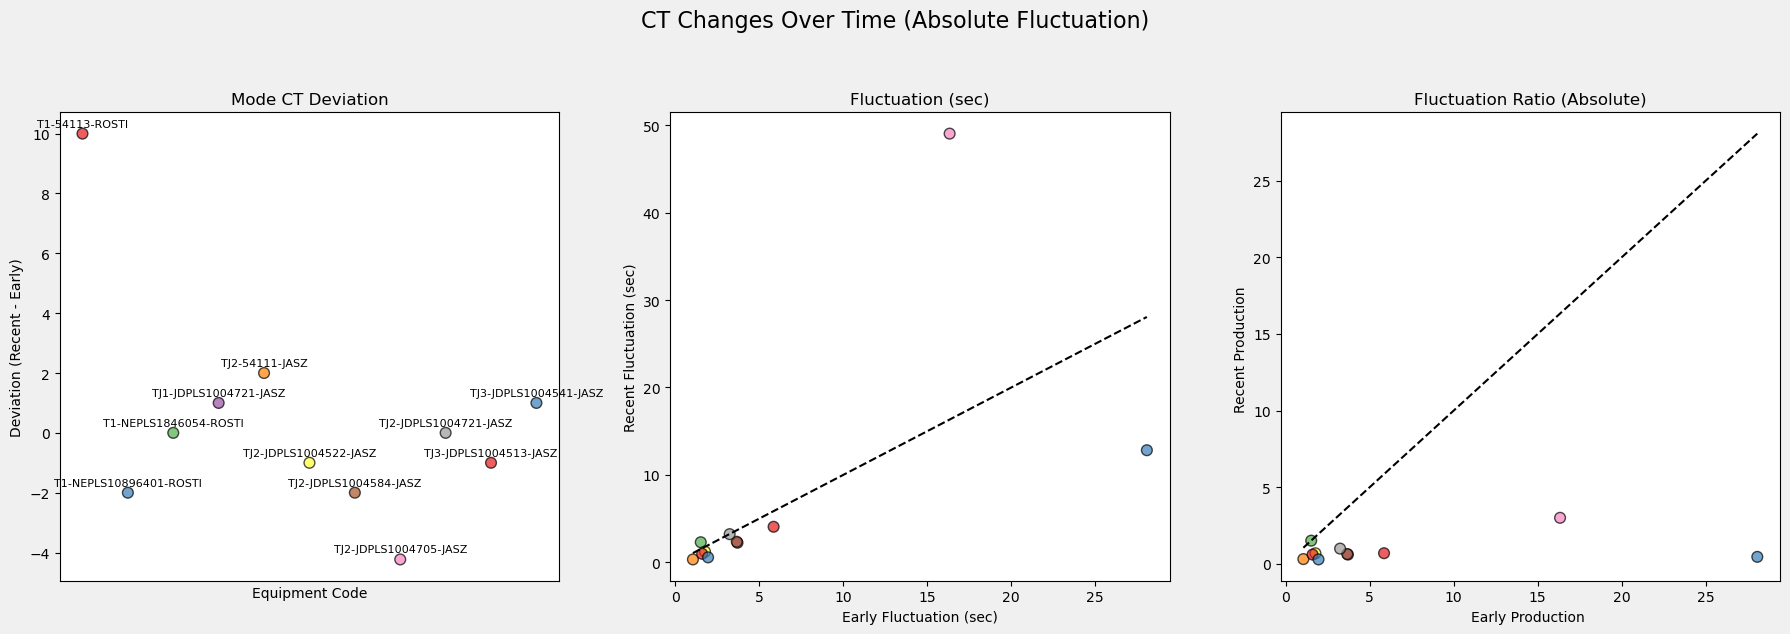


Toolings meeting the criteria (at least 20 production days, at least 1000 shots): 11


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define functions for calculating mode cycle time and fluctuation
def get_mode_ct(tool_data):
    # Get the first 10 distinct production days (not just the first 10 calendar days)
    first_10_days = tool_data[tool_data['DAY'].isin(tool_data['DAY'].dropna().unique()[:10])]  # First 10 distinct days
    recent_10_days = tool_data[tool_data['DAY'] > tool_data['DAY'].max() - 10]  # Last 10 production days
    
    # Mode CT calculations for early and recent days
    early_mode_ct = first_10_days['AVG_VALID_CT'].mode().iloc[0] if not first_10_days['AVG_VALID_CT'].mode().empty else np.nan
    recent_mode_ct = recent_10_days['AVG_VALID_CT'].mode().iloc[0] if not recent_10_days['AVG_VALID_CT'].mode().empty else np.nan
    
    return pd.Series({
        'early_mode_ct': early_mode_ct,
        'recent_mode_ct': recent_mode_ct
    })

def calculate_fluctuation(tool_data):
    # Get the first 10 distinct production days and the most recent 10 production days
    first_10_days = tool_data[tool_data['DAY'].isin(tool_data['DAY'].dropna().unique()[:10])]  # First 10 distinct days
    recent_10_days = tool_data[tool_data['DAY'] > tool_data['DAY'].max() - 10]  # Last 10 production days
    
    # Handle cases with insufficient data for fluctuation calculation
    early_fluctuation = first_10_days['AVG_VALID_CT'].std() if len(first_10_days) > 1 else np.nan
    recent_fluctuation = recent_10_days['AVG_VALID_CT'].std() if len(recent_10_days) > 1 else np.nan
    
    return pd.Series({
        'early_fluctuation': early_fluctuation,
        'recent_fluctuation': recent_fluctuation
    })

# Filter data for Jasz Plastics and Rosti
filtered_data = df[df['COMPANY_NAME'].isin(['Jasz Plasztik Ltd', 'Rosti'])]

# Condition 1: At least 20 production days
production_days_count = filtered_data.groupby('EQUIPMENT_CODE')['DAY'].nunique()
valid_tools_by_days = production_days_count[production_days_count >= 20]
print("Valid tools by production days (at least 20):")
print(valid_tools_by_days)

# Condition 2: At least 1000 shots
shots_count = filtered_data.groupby('EQUIPMENT_CODE')['AVG_VALID_CT'].count()
valid_tools_by_shots = shots_count[shots_count >= 1000]
print("\nValid tools by shots count (at least 1000):")
print(valid_tools_by_shots)

# Filter tools that meet both conditions
valid_tools = valid_tools_by_days.index.intersection(valid_tools_by_shots.index)
filtered_valid_tools = filtered_data[filtered_data['EQUIPMENT_CODE'].isin(valid_tools)]
print("\nFiltered tools meeting both conditions:")
print(filtered_valid_tools)

# Proceed with your analysis using filtered_valid_tools
filtered_data = filtered_valid_tools

# Calculate the mode cycle time and fluctuation for each equipment
mode_ct = filtered_data.groupby('EQUIPMENT_CODE').apply(get_mode_ct)
print("\nMode cycle times for each tool (early and recent):")
print(mode_ct)

fluctuation_data = filtered_data.groupby('EQUIPMENT_CODE').apply(calculate_fluctuation)
print("\nFluctuation data for each tool (early and recent):")
print(fluctuation_data)

# Combine the results into one DataFrame
tooling_stats = pd.concat([mode_ct, fluctuation_data], axis=1).reset_index()
print("\nTooling statistics (mode CT and fluctuation):")
print(tooling_stats)

# Calculate fluctuation ratio (recent_fluctuation / early_fluctuation)
tooling_stats['fluctuation_ratio'] = tooling_stats['recent_fluctuation'] / tooling_stats['early_fluctuation']

# Create a color palette for each unique EQUIPMENT_CODE
color_palette = sns.color_palette("Set1", n_colors=len(tooling_stats['EQUIPMENT_CODE'].unique()))

# Map each EQUIPMENT_CODE to a color
equipment_code_to_color = {equipment: color_palette[i] for i, equipment in enumerate(tooling_stats['EQUIPMENT_CODE'].unique())}
tooling_stats['color'] = tooling_stats['EQUIPMENT_CODE'].map(equipment_code_to_color)

# Print tooling stats with color mapping
print("\nTooling stats with color mapping:")
print(tooling_stats)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Set the background color of the entire figure (optional)
fig.patch.set_facecolor('#f0f0f0')  # Light gray background

# Set the background color of each subplot (optional)
for ax in axes:
    ax.set_facecolor('#ffffff')  # White background for each subplot

# Frame 1: Mode CT Deviation with expanded color palette
scatter1 = axes[0].scatter(tooling_stats['EQUIPMENT_CODE'], tooling_stats['recent_mode_ct'] - tooling_stats['early_mode_ct'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')

# Annotating each point with its EQUIPMENT_CODE
for i, row in tooling_stats.iterrows():
    axes[0].annotate(row['EQUIPMENT_CODE'], 
                     (row['EQUIPMENT_CODE'], row['recent_mode_ct'] - row['early_mode_ct']),
                     textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

axes[0].set_title("Mode CT Deviation")
axes[0].set_xlabel("Equipment Code")
axes[0].set_ylabel("Deviation (Recent - Early)")
axes[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Frame 2: Fluctuation (Recent vs Early) with diagonal reference line
scatter2 = axes[1].scatter(tooling_stats['early_fluctuation'], tooling_stats['recent_fluctuation'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')
axes[1].plot([tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             [tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             color='black', linestyle='--')
axes[1].set_title("Fluctuation (sec)")
axes[1].set_xlabel("Early Fluctuation (sec)")
axes[1].set_ylabel("Recent Fluctuation (sec)")

# Frame 3: Fluctuation Ratio (Absolute) comparison
scatter3 = axes[2].scatter(tooling_stats['early_fluctuation'], tooling_stats['fluctuation_ratio'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')
axes[2].plot([tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             [tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             color='black', linestyle='--')
axes[2].set_title("Fluctuation Ratio (Absolute)")
axes[2].set_xlabel("Early Production ")
axes[2].set_ylabel("Recent Production ")

# Add a main title for the entire figure (adjust y-position to add padding)
fig.suptitle("CT Changes Over Time (Absolute Fluctuation)", fontsize=16, y=1.05)

# Add padding between subplots
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Tight layout
plt.tight_layout()
plt.show()

# Print out how many toolings met the criteria
print(f"\nToolings meeting the criteria (at least 20 production days, at least 1000 shots): {len(valid_tools)}")


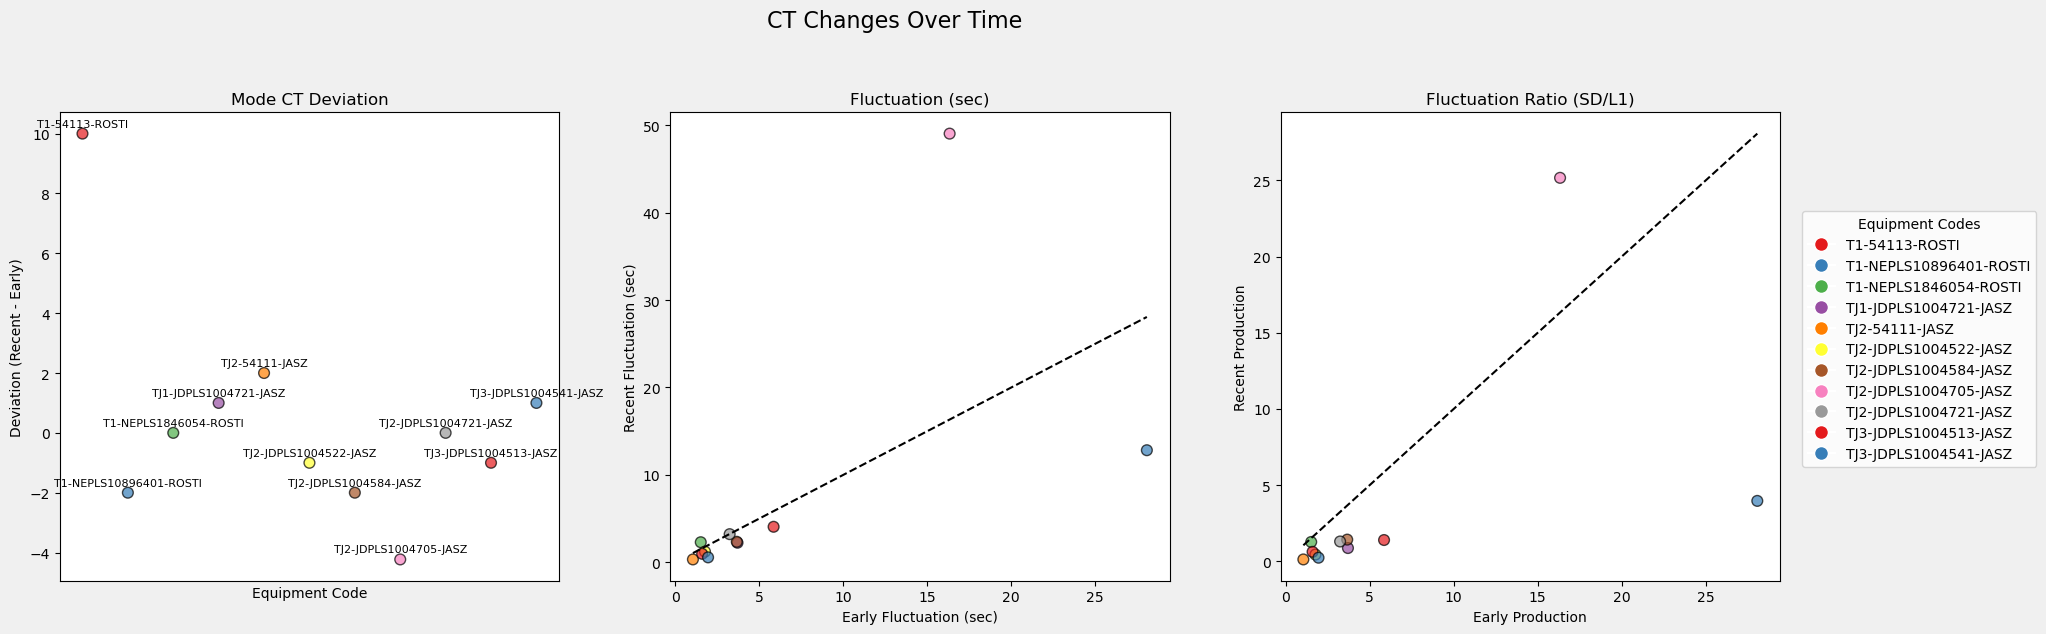

Equipment Codes and their Color Information:
Equipment Code: T1-54113-ROSTI, Color (RGB): (0.8941176470588236, 0.10196078431372549, 0.10980392156862745)
Equipment Code: T1-NEPLS10896401-ROSTI, Color (RGB): (0.21568627450980393, 0.49411764705882355, 0.7215686274509804)
Equipment Code: T1-NEPLS1846054-ROSTI, Color (RGB): (0.30196078431372547, 0.6862745098039216, 0.2901960784313726)
Equipment Code: TJ1-JDPLS1004721-JASZ, Color (RGB): (0.596078431372549, 0.3058823529411765, 0.6392156862745098)
Equipment Code: TJ2-54111-JASZ, Color (RGB): (1.0, 0.4980392156862745, 0.0)
Equipment Code: TJ2-JDPLS1004522-JASZ, Color (RGB): (1.0, 1.0, 0.2)
Equipment Code: TJ2-JDPLS1004584-JASZ, Color (RGB): (0.6509803921568628, 0.33725490196078434, 0.1568627450980392)
Equipment Code: TJ2-JDPLS1004705-JASZ, Color (RGB): (0.9686274509803922, 0.5058823529411764, 0.7490196078431373)
Equipment Code: TJ2-JDPLS1004721-JASZ, Color (RGB): (0.6, 0.6, 0.6)
Equipment Code: TJ3-JDPLS1004513-JASZ, Color (RGB): (0.89411764705

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define functions for calculating mode cycle time and fluctuation
def get_mode_ct(tool_data):
    first_10_days = tool_data[tool_data['DAY'].isin(tool_data['DAY'].dropna().unique()[:10])]
    recent_10_days = tool_data[tool_data['DAY'] > tool_data['DAY'].max() - 10]
    
    early_mode_ct = first_10_days['AVG_VALID_CT'].mode().iloc[0] if not first_10_days['AVG_VALID_CT'].mode().empty else np.nan
    recent_mode_ct = recent_10_days['AVG_VALID_CT'].mode().iloc[0] if not recent_10_days['AVG_VALID_CT'].mode().empty else np.nan
    
    return pd.Series({
        'early_mode_ct': early_mode_ct,
        'recent_mode_ct': recent_mode_ct
    })

def calculate_fluctuation(tool_data):
    first_10_days = tool_data[tool_data['DAY'].isin(tool_data['DAY'].dropna().unique()[:10])]
    recent_10_days = tool_data[tool_data['DAY'] > tool_data['DAY'].max() - 10]
    
    early_fluctuation = first_10_days['AVG_VALID_CT'].std() if len(first_10_days) > 1 else np.nan
    recent_fluctuation = recent_10_days['AVG_VALID_CT'].std() if len(recent_10_days) > 1 else np.nan
    
    return pd.Series({
        'early_fluctuation': early_fluctuation,
        'recent_fluctuation': recent_fluctuation
    })

# Filter data for Jasz Plastics and Rosti
filtered_data = df[df['COMPANY_NAME'].isin(['Jasz Plasztik Ltd', 'Rosti'])]

# Conditions for valid tools (at least 20 production days and 1000 shots)
production_days_count = filtered_data.groupby('EQUIPMENT_CODE')['DAY'].nunique()
valid_tools_by_days = production_days_count[production_days_count >= 20]
shots_count = filtered_data.groupby('EQUIPMENT_CODE')['AVG_VALID_CT'].count()
valid_tools_by_shots = shots_count[shots_count >= 1000]
valid_tools = valid_tools_by_days.index.intersection(valid_tools_by_shots.index)
filtered_valid_tools = filtered_data[filtered_data['EQUIPMENT_CODE'].isin(valid_tools)]

# Calculate the mode cycle time and fluctuation for each equipment
mode_ct = filtered_valid_tools.groupby('EQUIPMENT_CODE').apply(get_mode_ct)
fluctuation_data = filtered_valid_tools.groupby('EQUIPMENT_CODE').apply(calculate_fluctuation)

# Combine the results into one DataFrame and include AVG_VALID_CT
tooling_stats = pd.concat([mode_ct, fluctuation_data], axis=1).reset_index()
tooling_stats['AVG_VALID_CT'] = filtered_valid_tools.groupby('EQUIPMENT_CODE')['AVG_VALID_CT'].mean().values

# ACT Calculation: ACT is 5% of AVG_VALID_CT
tooling_stats['ACT'] = tooling_stats['AVG_VALID_CT'] * 0.05

# Update fluctuation ratio to use ACT instead of absolute fluctuation
tooling_stats['fluctuation_ratio'] = tooling_stats['recent_fluctuation'] / tooling_stats['ACT']

# Create a color palette for each unique EQUIPMENT_CODE
color_palette = sns.color_palette("Set1", n_colors=len(tooling_stats['EQUIPMENT_CODE'].unique()))
equipment_code_to_color = {equipment: color_palette[i] for i, equipment in enumerate(tooling_stats['EQUIPMENT_CODE'].unique())}
tooling_stats['color'] = tooling_stats['EQUIPMENT_CODE'].map(equipment_code_to_color)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Set the background color of the entire figure
fig.patch.set_facecolor('#f0f0f0')  # Light gray background

# Set the background color of each subplot
for ax in axes:
    ax.set_facecolor('#ffffff')  # White background for each subplot

# Frame 1: Mode CT Deviation
scatter1 = axes[0].scatter(tooling_stats['EQUIPMENT_CODE'], tooling_stats['recent_mode_ct'] - tooling_stats['early_mode_ct'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')

# Annotating each point with its EQUIPMENT_CODE
for i, row in tooling_stats.iterrows():
    axes[0].annotate(row['EQUIPMENT_CODE'], 
                     (row['EQUIPMENT_CODE'], row['recent_mode_ct'] - row['early_mode_ct']),
                     textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

axes[0].set_title("Mode CT Deviation")
axes[0].set_xlabel("Equipment Code")
axes[0].set_ylabel("Deviation (Recent - Early)")
axes[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Frame 2: Fluctuation (Recent vs Early) with diagonal reference line
scatter2 = axes[1].scatter(tooling_stats['early_fluctuation'], tooling_stats['recent_fluctuation'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')

# Add diagonal reference line
axes[1].plot([tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             [tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             color='black', linestyle='--')
axes[1].set_title("Fluctuation (sec)")
axes[1].set_xlabel("Early Fluctuation (sec)")
axes[1].set_ylabel("Recent Fluctuation (sec)")

# Frame 3: Fluctuation Ratio (Absolute) comparison
scatter3 = axes[2].scatter(tooling_stats['early_fluctuation'], tooling_stats['fluctuation_ratio'],
                           c=tooling_stats['color'], s=60, alpha=0.7, edgecolor='k')

# Add diagonal reference line
axes[2].plot([tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             [tooling_stats['early_fluctuation'].min(), tooling_stats['early_fluctuation'].max()],
             color='black', linestyle='--')
axes[2].set_title("Fluctuation Ratio (SD/L1)")
axes[2].set_xlabel("Early Production")
axes[2].set_ylabel("Recent Production")

# Add a main title for the entire figure
fig.suptitle("CT Changes Over Time", fontsize=16, y=1.05)

# Add padding between subplots
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Create a single legend for the entire figure
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) 
           for color in color_palette]
labels = list(tooling_stats['EQUIPMENT_CODE'].unique())
fig.legend(handles, labels, title="Equipment Codes", loc='center left', bbox_to_anchor=(1, 0.5))

# Tight layout for the plot
plt.tight_layout()
plt.show()

# Print out all the equipment codes and their corresponding color indices and RGB values
print("Equipment Codes and their Color Information:")
for i, row in tooling_stats.iterrows():
    equipment_code = row['EQUIPMENT_CODE']
    color = row['color']
    print(f"Equipment Code: {equipment_code}, Color (RGB): {color}")

# Print out how many toolings met the criteria
print(f"\nToolings meeting the criteria (at least 20 production days, at least 1000 shots): {len(valid_tools)}")


Analysis of tooling utilization rates


In [9]:
# Filter data for Jasz Plastics and Rosti
filtered_data2 = df[df['COMPANY_NAME'].isin(['Jasz Plasztik Ltd', 'Rosti'])]

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/2694230519.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/2694230519.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['Utilization_Bin'] = pd.cut(


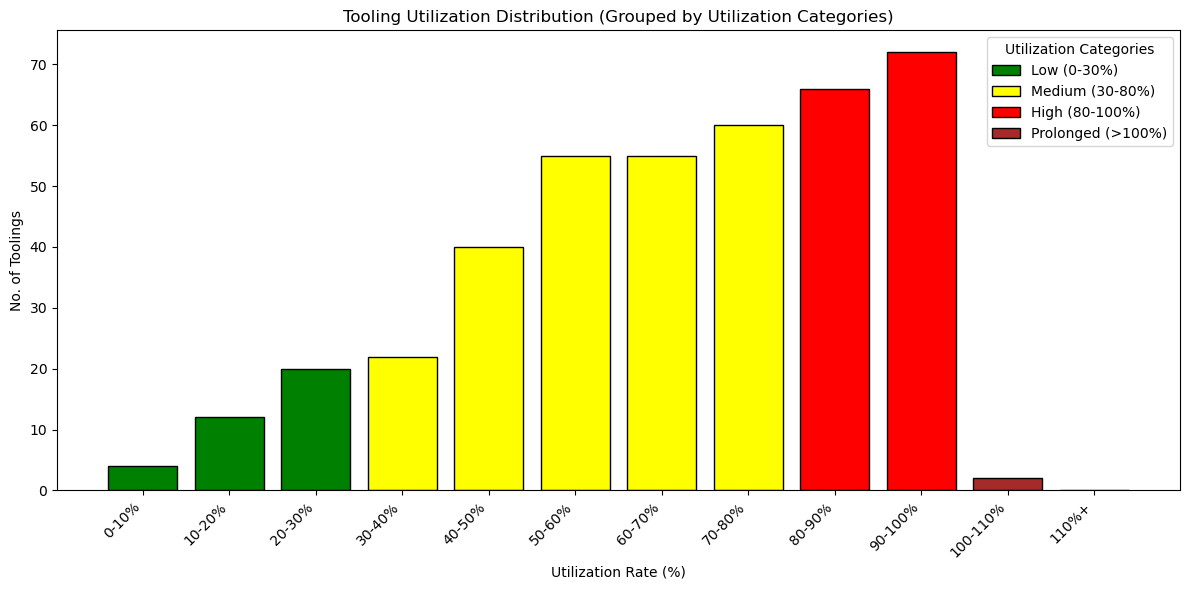

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate Utilization Rate
filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100

# Define 10% utilization bins
bins = list(range(0, 111, 10)) + [float('inf')]  # 0-10, 10-20, ..., 100-110, 110%+
labels = [f'{i}-{i+10}%' for i in range(0, 100, 10)] + ['100-110%', '110%+']

# Categorize utilization into bins
filtered_data2['Utilization_Bin'] = pd.cut(
    filtered_data2['UTILIZATION_RATE'], 
    bins=bins, 
    labels=labels, 
    right=False
)

# Count unique EQUIPMENT_CODE in each bin
bin_counts = filtered_data2.groupby('Utilization_Bin')['EQUIPMENT_CODE'].nunique().fillna(0)

# Define colors based on utilization ranges
color_mapping = {
    'Low (0-30%)': 'green',
    'Medium (30-80%)': 'yellow',
    'High (80-100%)': 'red',
    'Prolonged (>100%)': 'brown'
}

colors = []
for label in labels:
    if label == '110%+':
        colors.append('brown')  # Prolonged
    else:
        lower, upper = map(float, label.replace('%', '').split('-'))
        if upper <= 30:
            colors.append('green')  # Low
        elif upper <= 80:
            colors.append('yellow')  # Medium
        elif upper <= 100:
            colors.append('red')  # High
        else:
            colors.append('brown')  # Prolonged

# Plotting the distribution
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(bin_counts.index, bin_counts.values, color=colors, edgecolor='black', width=0.8)

# Add legend manually
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Low (0-30%)'),
    Patch(facecolor='yellow', edgecolor='black', label='Medium (30-80%)'),
    Patch(facecolor='red', edgecolor='black', label='High (80-100%)'),
    Patch(facecolor='brown', edgecolor='black', label='Prolonged (>100%)')
]

ax.legend(handles=legend_elements, title='Utilization Categories', loc='upper right')

# Titles and Labels
plt.title('Tooling Utilization Distribution (Grouped by Utilization Categories)')
plt.xlabel('Utilization Rate (%)')
plt.ylabel('No. of Toolings')
plt.xticks(rotation=45, ha='right')

# Improve spacing
plt.tight_layout()
plt.show()


In [11]:
filtered_data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35601 entries, 0 to 672693
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   COMPANY_NAME           35601 non-null  object  
 1   PLANT_NAME             35601 non-null  object  
 2   EQUIPMENT_CODE         35601 non-null  object  
 3   COUNTER_CODE           35601 non-null  object  
 4   SHOT_START_TIME        35601 non-null  int64   
 5   SHOT_END_TIME          35601 non-null  int64   
 6   CYCLE_TIME_LIMIT1      35601 non-null  float64 
 7   CYCLE_TIME_LIMIT1UNIT  35601 non-null  object  
 8   CYCLE_TIME_LIMIT2      35601 non-null  float64 
 9   CYCLE_TIME_LIMIT2UNIT  35601 non-null  object  
 10  L1_ABOVE_ADJUSTED      35601 non-null  float64 
 11  L2_ABOVE_ADJUSTED      35601 non-null  float64 
 12  L1_BELOW_ADJUSTED      35601 non-null  float64 
 13  L2_BELOW_ADJUSTED      35601 non-null  float64 
 14  CONTRACTED_CYCLE_TIME  35601 non-null  flo

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/3486607109.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/3486607109.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['Utilization_Bin'] = pd.cut(filtered_data2['UTILIZATION_RATE'], bins=bins, labels=labels, right=False)


<Figure size 1400x800 with 0 Axes>

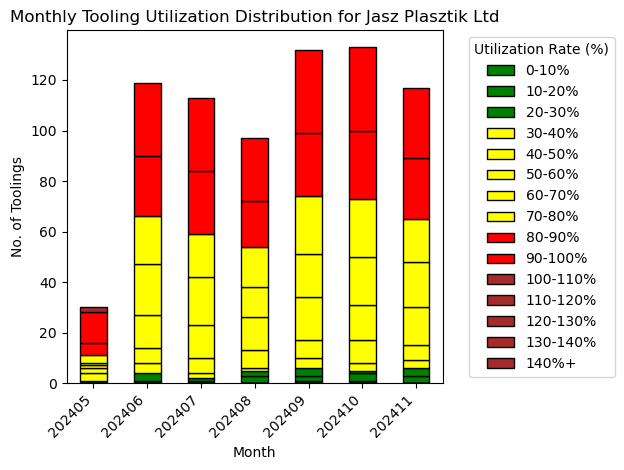

<Figure size 1400x800 with 0 Axes>

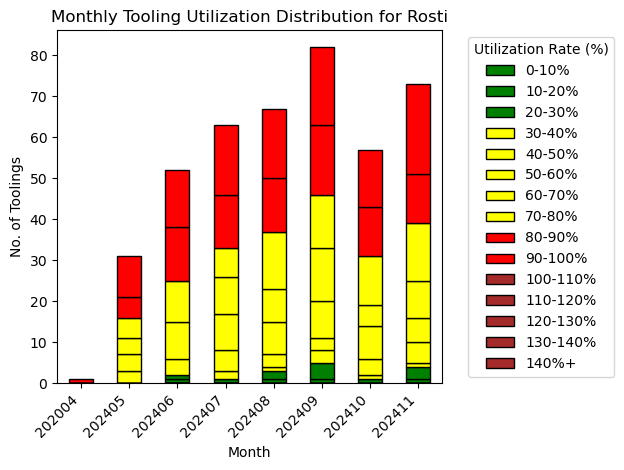

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the necessary data

# Calculate Utilization Rate
filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100

# Define 10% utilization bins
bins = list(range(0, 141, 10)) + [float('inf')]  # 0-10, 10-20, ..., 130-140, 140%+
labels = [f'{i}-{i+10}%' for i in range(0, 130, 10)] + ['130-140%', '140%+']

# Categorize utilization into bins
filtered_data2['Utilization_Bin'] = pd.cut(filtered_data2['UTILIZATION_RATE'], bins=bins, labels=labels, right=False)

# Define a list of suppliers
suppliers = ['Jasz Plasztik Ltd', 'Rosti']

# Define colors based on utilization ranges
colors = []
for label in labels:
    if label == '140%+':
        colors.append('brown')  # Prolonged
    else:
        lower, upper = map(float, label.replace('%', '').split('-'))
        if upper <= 30:
            colors.append('green')  # Low
        elif upper <= 80:
            colors.append('yellow')  # Medium
        elif upper <= 100:
            colors.append('red')  # High
        else:
            colors.append('brown')  # Prolonged

# Plotting the distribution for each supplier separately
for supplier in suppliers:
    # Filter data for the current supplier
    supplier_data = filtered_data2[filtered_data2['COMPANY_NAME'] == supplier]

    # Group by month and calculate the count of unique EQUIPMENT_CODE in each bin
    month_bin_counts = supplier_data.groupby(['MONTH', 'Utilization_Bin'])['EQUIPMENT_CODE'].nunique().unstack().fillna(0)

    # Plotting for the current supplier
    plt.figure(figsize=(14, 8))

    # Plot each month's data as a stacked bar
    month_bin_counts.plot(kind='bar', stacked=True, color=colors, edgecolor='black')

    plt.title(f'Monthly Tooling Utilization Distribution for {supplier}')
    plt.xlabel('Month')
    plt.ylabel('No. of Toolings')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Utilization Rate (%)', labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Show the plot for this supplier
    plt.show()


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the data based on the provided sample (Tooling ID, Utilization Rate, Supplier)
data = {
    'Tooling_ID': [
        'TJ2-JDPLS1004721-JASZ', 'TJ1-JDPLS1004721-JASZ', 'TJ1-JDPLS1004495-JASZ', 
        'TJ1-JDPLS1004541-JASZ', 'TJ1-JDPLS1004522-JASZ', 'TJ1-JDPLS1004513-JASZ',
        'TJ3-JDPLS1004541-JASZ', 'TJ2-JDPLS1004538-JASZ', 'TJ2-JDPLS1004705-JASZ',
        'TJ2-JDPLS1004541-JASZ', 'TJ2-JDPLS1004522-JASZ', 'T1-NEPLS1846054-ROSTI',
        'TJ2-JDPLS1004513-JASZ', 'TJ2-54111-JASZ', 'TJ3-JDPLS1004513-JASZ', 
        'TJ2-JDPLS1004495-JASZ', 'T1-54113-ROSTI', 'TJ1-54102-JASZ', 'TJ2-54107-JASZ',
        'TJ1-54125-JASZ','TJ2-54100-JASZ','T2-54410','T2-54400-ROSTI',' TJ2-JDPLS1004584-JASZ','TJ2-54106-JASZ','TJ1-54103-JASZ','TJ1-54120-JASZ',
        'T1-54428-ROSTI','T1-NEPLS1846103-ROSTI','T1-54429-ROSTI','T1-54403-ROSTI','TJ1-54105-JASZ','T1-54110-ROSTI','TJ1-54108-JASZ','T1-54460-ROSTI','T1-54402-ROSTI',
        'TJ1-92157-JASZ','TJ3-54106-JASZ','T1-54412-ROSTI','TJ3-JDPLS1004522-JASZ','T1-54404-ROSTI','TJ1-54126-JASZ','TJ1-54419-JASZ','T1-54124-ROSTI',
        'TJ3-54120-JASZ','T1-NEPLS2308084-ROSTI','T1-54420-ROSTI','T1-NEPLS2247002-ROSTI','T1-NEPLS1846024-ROSTI','T1-NEPLS2121001-ROSTI','TJ1-54104-JASZ',
        'TJ1-54119-JASZ','TJ1-54572-JASZ','TJ2-54103-JASZ','T1-54435-ROSTI','T1-NEPLS10896401-ROSTI',' TJ3-JDPLS1004721-JASZ','TJ1-54111-JASZ','TJ4-54111-JASZ','T1-54465-ROSTI',
        'TJ1-54123-JASZ','T1-54118-ROSTI','T1-54421-ROSTI','TJ4-JDPLS1004541-JASZ','TJ1-54144-JASZ','TJ3-54111-JASZ','T1-NEPLS1846044-ROSTI','TJ1-54127-JASZ',
        'T1-54151-ROSTI','TJ1-54107-JASZ','T1-54427-ROSTI','T1-54152-ROSTI','TJ2-54102-JASZ','T2-54427-ROSTI','TJ2-54120-JASZ','TJ5-JDPLS1004721-JASZ','TJ1-54106-JASZ',
        'T1-54400-ROSTI','T2-54113-ROSTI',' T1-54410-ROSTI','TJ2-54125-JASZ','TJ1-JDPLS1004538-JASZ'
    ],
    'Utilization_Rate': [
        263.9, 242.3, 175.8, 167.4, 163.0, 147.7, 88.1, 53.2, 48.8, 45.8, 40.1, 38.6,
        31.0, 29.5, 26.0, 23.8, 23.7, 20.6, 20.1, 19.9, 19.3, 18.6, 18.3, 15.6,15.4, 14.7,
        13.8, 13.5 , 12.3, 11.4 , 10.9, 10.9, 10.7,10.5,10.4,10.2,10.1,10.0,9.9,9.9,9.7,9.6,
        9.6,9.4,9.3,9.3,9.2,8.9,8.6,8.6,8.0,7.9,6.9,6.9,6.8,6.6,6.6,6.4,6.2,5.6,5.5,5.2,
        5.0,4.6,4.4,4.4,4.3,4.1,3.4,1.9,1.4,0.6,0.5,0.3,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.0
        
    ],
    'Supplier': [
        'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Rosti', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Rosti', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik','Jasz Plasztik','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik',
        'Rosti','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Rosti','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik',
        'Rosti','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Jasz Plasztik',
        'Rosti','Rosti','Jasz Plasztik','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik'
        
    ]
}

# Create DataFrame from the data
df2 = pd.DataFrame(data)

# Check the first few rows
print(df.head())


         COMPANY_NAME               PLANT_NAME  EQUIPMENT_CODE   COUNTER_CODE  \
0               Rosti             Rosti Poland  T1-54110-ROSTI  EMA2324M10928   
1       WIK Macedonia  Prilep, North Macedonia  9770.12-020T11  EMA2324M11490   
2           WIK Batam     WIK Batam, Indonesia   9781.12-011T5  EMA2252M10434   
3  Switzerland Nolato                Nolato CH        T2-18239  EMA2303M10685   
4           WIK Batam     WIK Batam, Indonesia  9744.12-028T19  EMA2324M11666   

       SHOT_START_TIME        SHOT_END_TIME  CYCLE_TIME_LIMIT1  \
0  1720377539000000000  1720381152000000000                5.0   
1  1728328070000000000  1728331650000000000                5.0   
2  1692668339000000000  1692671922000000000                5.0   
3  1717085400000000000  1717088975000000000                5.0   
4  1731111226000000000  1731114812000000000                5.0   

  CYCLE_TIME_LIMIT1UNIT  CYCLE_TIME_LIMIT2 CYCLE_TIME_LIMIT2UNIT  ...  \
0            PERCENTAGE               10.0 

In [14]:
df2.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tooling_ID        82 non-null     object 
 1   Utilization_Rate  82 non-null     float64
 2   Supplier          82 non-null     object 
dtypes: float64(1), object(2)
memory usage: 2.0+ KB


Utilization Rate Bins and Number of Tools for Jasz Plasztik:
         Bin  Jasz Plasztik
0      0-10%             23
1     10-20%             10
2     20-30%              5
3     30-40%              1
4     40-50%              3
5     50-60%              1
6     60-70%              0
7     70-80%              0
8     80-90%              1
9    90-100%              0
10  100-110%              0
11  110-120%              0
12  120-130%              0
13  130-140%              0
14  140-150%              1
15  150-160%              0
16  160-170%              2
17  170-180%              1
18  180-190%              0
19  190-200%              0
20  200-210%              0
21  210-220%              0
22  220-230%              0
23  230-240%              0
24  240-250%              1
25  250-260%              0
26  260-270%              1
27     263%+              0

Utilization Rate Bins and Number of Tools for Rosti:
         Bin  Rosti
0      0-10%     21
1     10-20%      9
2     20-30% 

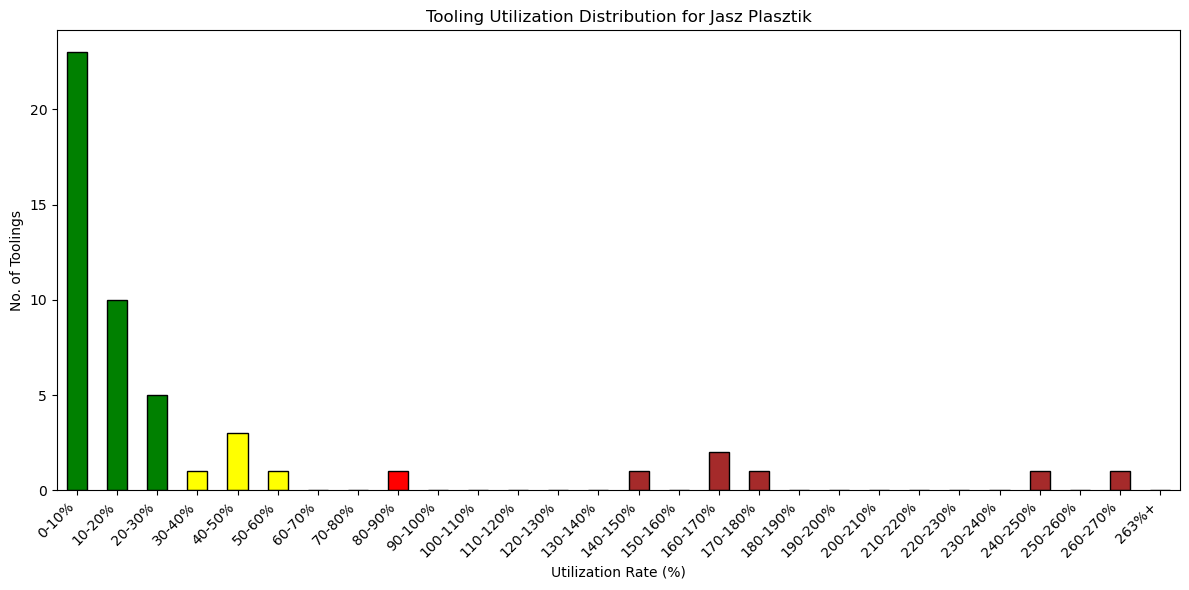

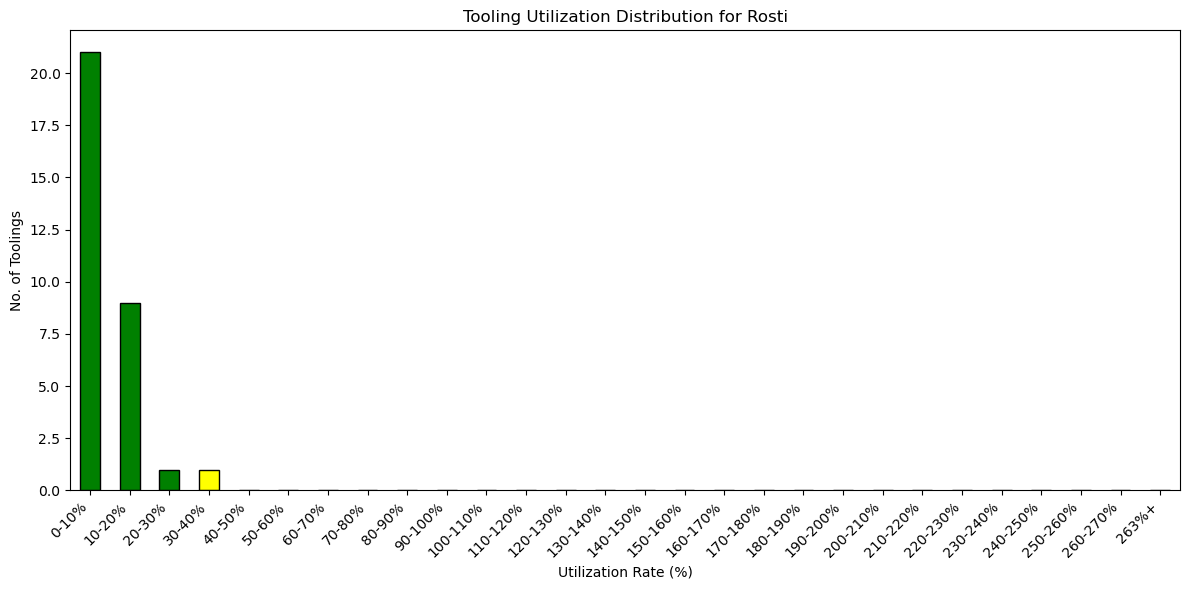

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `df` is your DataFrame with the necessary data

# Define dynamic bins based on the max utilization value
max_utilization = df2['Utilization_Rate'].max()
bins = list(range(0, int(max_utilization) + 10, 10)) + [float('inf')]  # Create bins up to the max value
labels = [f'{i}-{i+10}%' for i in range(0, int(max_utilization), 10)] + [f'{int(max_utilization)}%+']

# Categorize utilization into bins
df2['Utilization_Bin'] = pd.cut(df2['Utilization_Rate'], bins=bins, labels=labels, right=False)

# Group by company and calculate the count of unique Tooling_ID in each bin
company_bin_counts = df2.groupby(['Supplier', 'Utilization_Bin'])['Tooling_ID'].nunique().fillna(0).unstack()

# Print the bin counts for each company
for company in company_bin_counts.index:
    print(f"Utilization Rate Bins and Number of Tools for {company}:")
    print(company_bin_counts.loc[company].reset_index().rename(columns={'Utilization_Bin': 'Bin', 'Tooling_ID': 'No. of Tools'}))
    print()

# Define colors based on utilization ranges
colors = []
for label in labels:
    if label.endswith('%+'):
        colors.append('brown')  # Prolonged
    else:
        lower, upper = map(int, label.replace('%', '').split('-'))
        if upper <= 30:
            colors.append('green')  # Low
        elif upper <= 80:
            colors.append('yellow')  # Medium
        elif upper <= 100:
            colors.append('red')  # High
        else:
            colors.append('brown')  # Prolonged

# Plotting the distribution for each company
for company in company_bin_counts.index:
    plt.figure(figsize=(12, 6))
    bin_counts = company_bin_counts.loc[company]
    bin_counts.plot(kind='bar', color=colors, edgecolor='black')
    plt.title(f'Tooling Utilization Distribution for {company}')
    plt.xlabel('Utilization Rate (%)')
    plt.ylabel('No. of Toolings')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


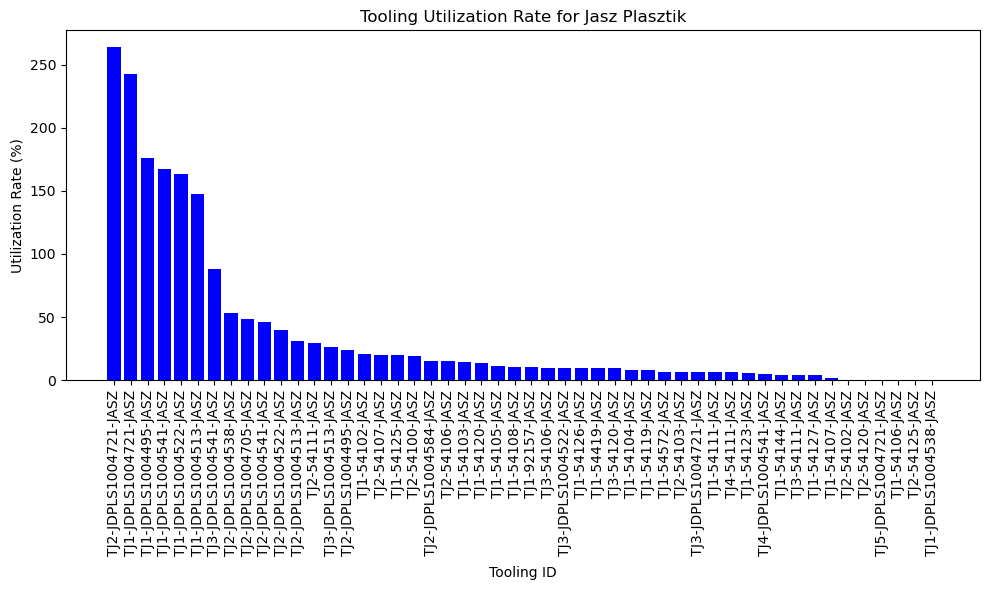

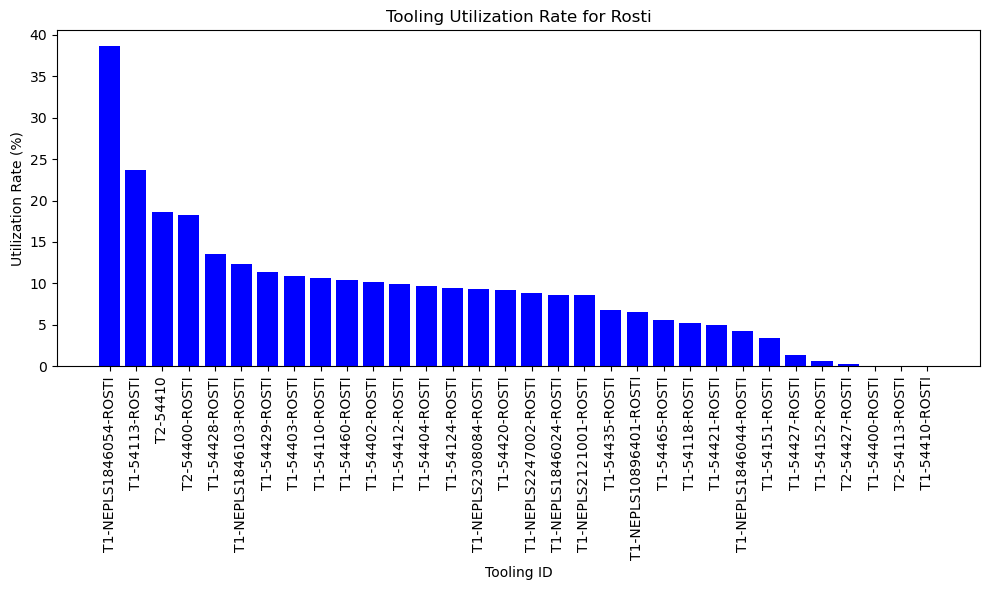

In [16]:
# Create separate plots for each supplier
suppliers = df2['Supplier'].unique()

# Plotting the data
for supplier in suppliers:
    plt.figure(figsize=(10, 6))
    
    # Filter data for the current supplier
    supplier_data = df2[df2['Supplier'] == supplier]
    
    # Plotting utilization rates
    plt.bar(supplier_data['Tooling_ID'], supplier_data['Utilization_Rate'], color='blue')
    
    plt.title(f'Tooling Utilization Rate for {supplier}')
    plt.xlabel('Tooling ID')
    plt.ylabel('Utilization Rate (%)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/3486607109.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_23777/3486607109.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data2['Utilization_Bin'] = pd.cut(filtered_data2['UTILIZATION_RATE'], bins=bins, labels=labels, right=False)


<Figure size 1400x800 with 0 Axes>

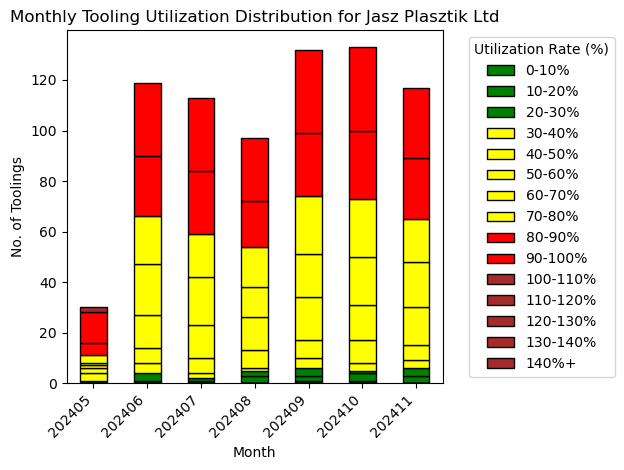

<Figure size 1400x800 with 0 Axes>

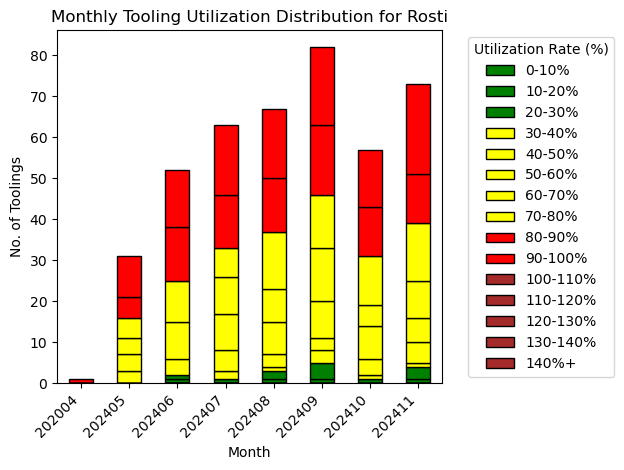

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame with the necessary data

# Calculate Utilization Rate
filtered_data2['UTILIZATION_RATE'] = (filtered_data2['PRODUCTION_TIME'] / filtered_data2['TOTAL_SESSION_TIME']) * 100

# Define 10% utilization bins
bins = list(range(0, 141, 10)) + [float('inf')]  # 0-10, 10-20, ..., 130-140, 140%+
labels = [f'{i}-{i+10}%' for i in range(0, 130, 10)] + ['130-140%', '140%+']

# Categorize utilization into bins
filtered_data2['Utilization_Bin'] = pd.cut(filtered_data2['UTILIZATION_RATE'], bins=bins, labels=labels, right=False)

# Define a list of suppliers
suppliers = ['Jasz Plasztik Ltd', 'Rosti']

# Define colors based on utilization ranges
colors = []
for label in labels:
    if label == '140%+':
        colors.append('brown')  # Prolonged
    else:
        lower, upper = map(float, label.replace('%', '').split('-'))
        if upper <= 30:
            colors.append('green')  # Low
        elif upper <= 80:
            colors.append('yellow')  # Medium
        elif upper <= 100:
            colors.append('red')  # High
        else:
            colors.append('brown')  # Prolonged

# Plotting the distribution for each supplier separately
for supplier in suppliers:
    # Filter data for the current supplier
    supplier_data = filtered_data2[filtered_data2['COMPANY_NAME'] == supplier]

    # Group by month and calculate the count of unique EQUIPMENT_CODE in each bin
    month_bin_counts = supplier_data.groupby(['MONTH', 'Utilization_Bin'])['EQUIPMENT_CODE'].nunique().unstack().fillna(0)

    # Plotting for the current supplier
    plt.figure(figsize=(14, 8))

    # Plot each month's data as a stacked bar
    month_bin_counts.plot(kind='bar', stacked=True, color=colors, edgecolor='black')

    plt.title(f'Monthly Tooling Utilization Distribution for {supplier}')
    plt.xlabel('Month')
    plt.ylabel('No. of Toolings')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Utilization Rate (%)', labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Show the plot for this supplier
    plt.show()


In [18]:
filtered_data2.head()

,COMPANY_NAME,PLANT_NAME,EQUIPMENT_CODE,COUNTER_CODE,SHOT_START_TIME,SHOT_END_TIME,CYCLE_TIME_LIMIT1,CYCLE_TIME_LIMIT1UNIT,CYCLE_TIME_LIMIT2,CYCLE_TIME_LIMIT2UNIT,...,END_TIME,IDLE_TIME,UPTIME_PERCENTAGE,DAY,MONTH,QUARTER,YEAR,WEEK,UTILIZATION_RATE,Utilization_Bin
0,Rosti,Rosti Poland,T1-54110-ROSTI,EMA2324M10928,1720377539000000000,1720381152000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,20240707 19:39:12,31,99.15,20240707,202407,20243,2024,202427,99.145299,90-100%
33,Jasz Plasztik Ltd,Jasz Hungary,TJ2-JDPLS1004522-JASZ,EMA2324M10582,1727987554000000000,1727991136000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,20241003 21:32:16,54,98.48,20241003,202410,20244,2024,202440,98.484848,90-100%
37,Jasz Plasztik Ltd,Jasz Hungary,TJ2-JDPLS1004721-JASZ,EMA2324M11293,1730198619000000000,1730202186000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,20241029 11:43:06,47,98.69,20241029,202410,20244,2024,202444,98.688982,90-100%
41,Jasz Plasztik Ltd,Jasz Hungary,TJ1-54108-JASZ,EMA2324M11291,1727184418000000000,1727187979000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,20240924 14:26:19,86,97.58,20240924,202409,20243,2024,202439,97.580191,90-100%
49,Rosti,Rosti Poland,T1-NEPLS2247002-ROSTI,EMA2324M11705,1718963672000000000,1718967267000000000,5.0,PERCENTAGE,10.0,PERCENTAGE,...,20240621 10:54:27,37,98.97,20240621,202406,20242,2024,202425,98.969072,90-100%


In [19]:
import plotly.express as px
import pandas as pd

# Filter data for 2024 only
filtered_data_2024 = filtered_data2[filtered_data2['YEAR'] == 2024]

# Separate the data for the two suppliers: 'Rosti' and 'Jasz Plasztik Ltd'
rosti_data = filtered_data_2024[filtered_data_2024['COMPANY_NAME'] == 'Rosti']
jasz_plasztik_data = filtered_data_2024[filtered_data_2024['COMPANY_NAME'] == 'Jasz Plasztik Ltd']

# Calculate the average uptime percentage for each EQUIPMENT_CODE and round to 2 decimal places
rosti_avg_data = rosti_data.groupby('EQUIPMENT_CODE')['UPTIME_PERCENTAGE'].mean().reset_index()
jasz_plasztik_avg_data = jasz_plasztik_data.groupby('EQUIPMENT_CODE')['UPTIME_PERCENTAGE'].mean().reset_index()

# Round the UPTIME_PERCENTAGE values to 2 decimal places
rosti_avg_data['UPTIME_PERCENTAGE'] = rosti_avg_data['UPTIME_PERCENTAGE'].round(2)
jasz_plasztik_avg_data['UPTIME_PERCENTAGE'] = jasz_plasztik_avg_data['UPTIME_PERCENTAGE'].round(2)

# Bar plot for Rosti grouped by EQUIPMENT_CODE (with average UPTIME_PERCENTAGE)
fig_rosti = px.bar(rosti_avg_data, 
                   x='EQUIPMENT_CODE', 
                   y='UPTIME_PERCENTAGE', 
                   title='Rosti Uptime Percentage by Equipment Code (2024)', 
                   labels={'UPTIME_PERCENTAGE': 'Uptime Percentage (%)', 'EQUIPMENT_CODE': 'Equipment Code'},
                   color='EQUIPMENT_CODE',  # Color bars by Equipment Code for differentiation
                   text='UPTIME_PERCENTAGE',  # Display values on bars
                   category_orders={'EQUIPMENT_CODE': sorted(rosti_avg_data['EQUIPMENT_CODE'].unique())})  # Sort the equipment codes

# Customize layout for Rosti
fig_rosti.update_layout(
    title='Rosti Uptime Percentage by Equipment Code (2024)',
    xaxis_title='Equipment Code',
    yaxis_title='Uptime Percentage (%)',
    yaxis=dict(range=[0, 100]),  # Explicitly set the y-axis range to 0-100%
    template='plotly',  # Optional: Choose a template
    showlegend=False,
    xaxis_tickangle=-45  # Rotate the equipment code labels for better readability
)

# Show the plot for Rosti
fig_rosti.show()

# Bar plot for Jasz Plasztik Ltd grouped by EQUIPMENT_CODE (with average UPTIME_PERCENTAGE)
fig_jasz_plasztik = px.bar(jasz_plasztik_avg_data, 
                           x='EQUIPMENT_CODE', 
                           y='UPTIME_PERCENTAGE', 
                           title='Jasz Plasztik Ltd Uptime Percentage by Equipment Code (2024)', 
                           labels={'UPTIME_PERCENTAGE': 'Uptime Percentage (%)', 'EQUIPMENT_CODE': 'Equipment Code'},
                           color='EQUIPMENT_CODE',  # Color bars by Equipment Code for differentiation
                           text='UPTIME_PERCENTAGE',  # Display values on bars
                           category_orders={'EQUIPMENT_CODE': sorted(jasz_plasztik_avg_data['EQUIPMENT_CODE'].unique())})  # Sort the equipment codes

# Customize layout for Jasz Plasztik Ltd
fig_jasz_plasztik.update_layout(
    title='Jasz Plasztik Ltd Uptime Percentage by Equipment Code (2024)',
    xaxis_title='Equipment Code',
    yaxis_title='Uptime Percentage (%)',
    yaxis=dict(range=[0, 100]),  # Explicitly set the y-axis range to 0-100%
    template='plotly_white',  # Optional: Choose a template
    showlegend=False,
    xaxis_tickangle=-45  # Rotate the equipment code labels for better readability
)

# Show the plot for Jasz Plasztik Ltd
fig_jasz_plasztik.show()


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the data based on the provided sample (Tooling ID, Utilization Rate, Supplier)
data = {
    'Tooling_ID': [
        'TJ2-JDPLS1004721-JASZ', 'TJ1-JDPLS1004721-JASZ', 'TJ1-JDPLS1004495-JASZ', 
        'TJ1-JDPLS1004541-JASZ', 'TJ1-JDPLS1004522-JASZ', 'TJ1-JDPLS1004513-JASZ',
        'TJ3-JDPLS1004541-JASZ', 'TJ2-JDPLS1004538-JASZ', 'TJ2-JDPLS1004705-JASZ',
        'TJ2-JDPLS1004541-JASZ', 'TJ2-JDPLS1004522-JASZ', 'T1-NEPLS1846054-ROSTI',
        'TJ2-JDPLS1004513-JASZ', 'TJ2-54111-JASZ', 'TJ3-JDPLS1004513-JASZ', 
        'TJ2-JDPLS1004495-JASZ', 'T1-54113-ROSTI', 'TJ1-54102-JASZ', 'TJ2-54107-JASZ',
        'TJ1-54125-JASZ','TJ2-54100-JASZ','T2-54410','T2-54400-ROSTI',' TJ2-JDPLS1004584-JASZ','TJ2-54106-JASZ','TJ1-54103-JASZ','TJ1-54120-JASZ',
        'T1-54428-ROSTI','T1-NEPLS1846103-ROSTI','T1-54429-ROSTI','T1-54403-ROSTI','TJ1-54105-JASZ','T1-54110-ROSTI','TJ1-54108-JASZ','T1-54460-ROSTI','T1-54402-ROSTI',
        'TJ1-92157-JASZ','TJ3-54106-JASZ','T1-54412-ROSTI','TJ3-JDPLS1004522-JASZ','T1-54404-ROSTI','TJ1-54126-JASZ','TJ1-54419-JASZ','T1-54124-ROSTI',
        'TJ3-54120-JASZ','T1-NEPLS2308084-ROSTI','T1-54420-ROSTI','T1-NEPLS2247002-ROSTI','T1-NEPLS1846024-ROSTI','T1-NEPLS2121001-ROSTI','TJ1-54104-JASZ',
        'TJ1-54119-JASZ','TJ1-54572-JASZ','TJ2-54103-JASZ','T1-54435-ROSTI','T1-NEPLS10896401-ROSTI',' TJ3-JDPLS1004721-JASZ','TJ1-54111-JASZ','TJ4-54111-JASZ','T1-54465-ROSTI',
        'TJ1-54123-JASZ','T1-54118-ROSTI','T1-54421-ROSTI','TJ4-JDPLS1004541-JASZ','TJ1-54144-JASZ','TJ3-54111-JASZ','T1-NEPLS1846044-ROSTI','TJ1-54127-JASZ',
        'T1-54151-ROSTI','TJ1-54107-JASZ','T1-54427-ROSTI','T1-54152-ROSTI','TJ2-54102-JASZ','T2-54427-ROSTI','TJ2-54120-JASZ','TJ5-JDPLS1004721-JASZ','TJ1-54106-JASZ',
        'T1-54400-ROSTI','T2-54113-ROSTI',' T1-54410-ROSTI','TJ2-54125-JASZ','TJ1-JDPLS1004538-JASZ'
    ],
    'Utilization_Rate': [
        263.9, 242.3, 175.8, 167.4, 163.0, 147.7, 88.1, 53.2, 48.8, 45.8, 40.1, 38.6,
        31.0, 29.5, 26.0, 23.8, 23.7, 20.6, 20.1, 19.9, 19.3, 18.6, 18.3, 15.6,15.4, 14.7,
        13.8, 13.5 , 12.3, 11.4 , 10.9, 10.9, 10.7,10.5,10.4,10.2,10.1,10.0,9.9,9.9,9.7,9.6,
        9.6,9.4,9.3,9.3,9.2,8.9,8.6,8.6,8.0,7.9,6.9,6.9,6.8,6.6,6.6,6.4,6.2,5.6,5.5,5.2,
        5.0,4.6,4.4,4.4,4.3,4.1,3.4,1.9,1.4,0.6,0.5,0.3,0.2,0.2,0.2,0.0,0.0,0.0,0.0,0.0
        
    ],
    
    'Supplier ID': [
        'JP-282','JP-281','JP-277','JP-278','JP-279','JP-283','JP-755','JP-749','JP-751','JP-753','JP-754','JB005',
        'JP-756','JP797','JP-863','JP-752','JB036','JP786','JP794','JP801','JP782','JB037C','JB052C','JP-750',
        'JP792','JP788','JP783','JB056','JB010','JB057','JB053','JP790','JB040','JP795','JB059','JB044','JP814',
        'JP817','JB047','JP-861','JB045','JP803','JP810','JB051','JP785','JB008','JB054','JB061','JB003','JB009',
        'JP813','JP800','JP811','JP789','JB049','JB060','JP-008','JP796','JP799','JB048','JP812','JB041','JB055',
        'JP-862','JP805','JP798','JB004','JP804','JB042','JP793','JB039','JB043','JP787','JB039C','JP784','JP-865',
        'JP791','JB052','JB036C','JB037','JP802','JP-272'
    
        
      
    ],
    'Total Shot Count': [
        2639178, 2423130, 1757784,1674461,1630081,1477038,881360,532200,488202,458323,400867,386019,310168,294818,259694,
        237910,236511,206048,200969,198943,192979,  186357, 182519,155759, 154399,146543,138065,134598,122929,114033,108919,
        108900,106999,104561,104497,101721,100950,99855,99018,98845,96879,96000,95839,94211,92618,92607,91607,89233,
        86246,86070,80297,79106,69031,68815,67510,66378,66352,63654,61820,55851,54932,51902,49906,45630,44207,
        43909,43365,41001,33742,18521,14420,5639,5000,2742,2019,1884,1527,294,291,215,196,114
        
        
    ],
    
    'Years Made': [
        'NoData','NoData','NoData','NoData','NoData','NoData','NoData','NoData','NoData','NoData','NoData',2020,'NoData',
        'NoData','NoData','NoData',2021,'NoData','NoData','NoData','NoData',2019,2021,'NoData','NoData','NoData','NoData',
        2021,2020,2021,2021,'NoData',2021,'NoData',2021,2021,'NoData','NoData',2021,'NoData',2021,'NoData','NoData',
        2021,'NoData',2020,2021,2023,2020,2020,'NoData','NoData','NoData','NoData',2021,2023,'NoData','NoData','NoData',
        2021,'NoData',2021,2021,'NoData','NoData','NoData',2020,'NoData',2021,'NoData',2021,2021,'NoData',2021,'NoData',
        'NoData','NoData',2021,2021,2021,'NoData','NoData'
        
        
     
        
    ],
    
    'Guranteed Shots': [
        
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,1000000,
        1000000,1000000
 
    ],
    
    'Last Shot Detected': [
        '2024-12-15','2024-12-05','2024-11-27','2024-11-28','2024-05-30','2024-06-11','2024-12-06','2024-11-22','2024-12-13','2024-12-09',
        '2024-12-06','2024-11-19','2024-10-26','2024-12-15','2024-12-13','2024-12-10','2024-12-08','2024-12-15','2024-12-12','2024-12-13',
        '2024-12-13','2024-12-19','2024-12-09','2024-11-27','2024-12-09','2024-07-19','2024-12-10','2024-12-04','2024-12-06',
        '2024-11-25','2024-11-20','2024-12-13','2024-10-26','2024-11-28','2024-12-06','2024-11-25','2024-12-04','2024-12-06',
        '2024-11-28','2024-06-12','2024-11-16','2024-11-23','2024-11-22','2024-11-11','2024-11-30','2024-11-25','2024-11-22','2024-11-21','2024-09-30',
        '2024-11-16','2024-11-18','2024-06-28','2024-12-11','2024-12-11','2024-05-20','2024-12-07','2024-10-24','2024-07-10','2024-09-16','2024-12-02',
        '2024-11-29','2024-11-19','2024-11-17','2024-06-24','2024-11-23','2024-09-13','2024-08-20','2024-07-30','2024-11-20','2024-12-15','2024-12-05',
        '2024-08-09','2024-12-12','2024-05-21','2024-10-08','2024-12-13','2024-10-09','2024-11-06','2024-12-12','2024-11-14','2024-05-31','2024-06-05'
        
    
    ],
    'Supplier': [
        'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Rosti', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik', 
        'Jasz Plasztik', 'Rosti', 'Jasz Plasztik', 'Jasz Plasztik', 'Jasz Plasztik','Jasz Plasztik','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik',
        'Rosti','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Rosti','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik',
        'Rosti','Jasz Plasztik','Rosti','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Jasz Plasztik','Rosti','Jasz Plasztik',
        'Rosti','Rosti','Jasz Plasztik','Rosti','Jasz Plasztik','Jasz Plasztik','Jasz Plasztik','Rosti','Rosti','Rosti',
        'Jasz Plasztik','Jasz Plasztik'
        
    ]
}

# Create DataFrame from the data
df3 = pd.DataFrame(data)

# Check the first few rows
print(df3.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Tooling_ID          82 non-null     object 
 1   Utilization_Rate    82 non-null     float64
 2   Supplier ID         82 non-null     object 
 3   Total Shot Count    82 non-null     int64  
 4   Years Made          82 non-null     object 
 5   Guranteed Shots     82 non-null     int64  
 6   Last Shot Detected  82 non-null     object 
 7   Supplier            82 non-null     object 
dtypes: float64(1), int64(2), object(5)
memory usage: 5.2+ KB
None


In [35]:
df3.head()  

,Tooling_ID,Utilization_Rate,Supplier ID,Total Shot Count,Years Made,Guranteed Shots,Last Shot Detected,Supplier
0,TJ2-JDPLS1004721-JASZ,263.9,JP-282,2639178,NoData,1000000,2024-12-15,Jasz Plasztik
1,TJ1-JDPLS1004721-JASZ,242.3,JP-281,2423130,NoData,1000000,2024-12-05,Jasz Plasztik
2,TJ1-JDPLS1004495-JASZ,175.8,JP-277,1757784,NoData,1000000,2024-11-27,Jasz Plasztik
3,TJ1-JDPLS1004541-JASZ,167.4,JP-278,1674461,NoData,1000000,2024-11-28,Jasz Plasztik
4,TJ1-JDPLS1004522-JASZ,163.0,JP-279,1630081,NoData,1000000,2024-05-30,Jasz Plasztik


In [36]:
df3['Remaining Shots'] = df3['Guranteed Shots'] - df3['Total Shot Count']   # Calculate the remaining shots

def category(rate):
    if rate <= 30:
        return 'Low'
    elif rate <= 80:
        return 'Medium'
    elif rate <= 100:
        return 'High'
    else:
        return 'Prolonged'
    
df3['category'] = df3['Utilization_Rate'].apply(category)  # Apply the function to create the category column 

print(df3.head())  

              Tooling_ID  Utilization_Rate Supplier ID  Total Shot Count  \
0  TJ2-JDPLS1004721-JASZ             263.9      JP-282           2639178   
1  TJ1-JDPLS1004721-JASZ             242.3      JP-281           2423130   
2  TJ1-JDPLS1004495-JASZ             175.8      JP-277           1757784   
3  TJ1-JDPLS1004541-JASZ             167.4      JP-278           1674461   
4  TJ1-JDPLS1004522-JASZ             163.0      JP-279           1630081   

  Years Made  Guranteed Shots Last Shot Detected       Supplier  \
0     NoData          1000000         2024-12-15  Jasz Plasztik   
1     NoData          1000000         2024-12-05  Jasz Plasztik   
2     NoData          1000000         2024-11-27  Jasz Plasztik   
3     NoData          1000000         2024-11-28  Jasz Plasztik   
4     NoData          1000000         2024-05-30  Jasz Plasztik   

   Remaining Shots   category  
0         -1639178  Prolonged  
1         -1423130  Prolonged  
2          -757784  Prolonged  
3          -

In [37]:
supplier_summary = df3.groupby('Supplier').agg(
    total_shot_count = ('Total Shot Count','sum'),
    total_guaranteed_shots = ('Guranteed Shots','sum'),
    total_remaining_shots = ('Remaining Shots','sum'),
).reset_index()

print(supplier_summary)

        Supplier  total_shot_count  total_guaranteed_shots  \
0  Jasz Plasztik          18404502                50000000   
1          Rosti           2913228                32000000   

   total_remaining_shots  
0               31595498  
1               29086772  


In [43]:
# Separate data by Supplier and maintain all columns
supplier_groups = {supplier: group for supplier, group in df3.groupby('Supplier')}

for supplier, group in supplier_groups.items():
    print(f"Supplier: {supplier}")
    print(group[['Tooling_ID', 'Supplier ID', 'Years Made', 'Total Shot Count', 'Guranteed Shots', 'Utilization_Rate', 'category', 'Remaining Shots', 'Last Shot Detected']])
    print("\n")
    
supplier_groups['Rosti'].head()

# # Save results to an Excel file
# with pd.ExcelWriter('supplier_data.xlsx') as writer:
#     for supplier, group in supplier_groups.items():
#         # Write each group (supplier's data) to a separate sheet in the Excel file
#         group[['Tooling_ID', 'Supplier ID', 'Years Made', 'Total Shot Count', 'Guranteed Shots', 'Utilization_Rate', 'category', 'Remaining Shots', 'Last Shot Detected']].to_excel(writer, sheet_name=supplier, index=False)

print("Data saved to supplier_data.xlsx")



Supplier: Jasz Plasztik
                Tooling_ID Supplier ID Years Made  Total Shot Count  \
0    TJ2-JDPLS1004721-JASZ      JP-282     NoData           2639178   
1    TJ1-JDPLS1004721-JASZ      JP-281     NoData           2423130   
2    TJ1-JDPLS1004495-JASZ      JP-277     NoData           1757784   
3    TJ1-JDPLS1004541-JASZ      JP-278     NoData           1674461   
4    TJ1-JDPLS1004522-JASZ      JP-279     NoData           1630081   
5    TJ1-JDPLS1004513-JASZ      JP-283     NoData           1477038   
6    TJ3-JDPLS1004541-JASZ      JP-755     NoData            881360   
7    TJ2-JDPLS1004538-JASZ      JP-749     NoData            532200   
8    TJ2-JDPLS1004705-JASZ      JP-751     NoData            488202   
9    TJ2-JDPLS1004541-JASZ      JP-753     NoData            458323   
10   TJ2-JDPLS1004522-JASZ      JP-754     NoData            400867   
12   TJ2-JDPLS1004513-JASZ      JP-756     NoData            310168   
13          TJ2-54111-JASZ       JP797     NoData    